<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune/"><strong>Linkedin</strong></a> •
</p>

# Black-Box Optimisation Capstone Tutorial: Bayesian Optimisation of F1–F8

After week 10, revisited where it started with a beginner's mind. This is the second diagnostics notebook after the `w0-beginner-mind-diagnostics.ipynb` study ranks Bayesian Optimisation (GP + EI) as the **best** strategy for this BBO. 

Eight unknown functions (`F1`–`F8`) with continuous inputs on $[0, 1]^d$ ($d \in [2, 8]$) were evaluated at an initial design set (`CapstoneFunction_from_Numpy.xlsx`). The goal is to recommend input points that maximise each target function using Bayesian Optimisation.

---

### Pipeline Overview

1. **Surrogate Modeling**
Fit a Gaussian Process Regressor (GPR) to each function's dataset.
2. **Model Selection (OAT Coordinate Search)**
Tune the kernel, $x$-input transformation, and $y$-output transformation using Leave-One-Out Cross-Validation (LOO-CV).
* **Search Palette:** 19 kernels $\times$ 2 $x$-transforms $\times$ 8 $y$-transforms (304 combinations in a full grid).
* **Execution:** Sweep one axis at a time while holding the others fixed (29 fits per pass). This coordinate-descent search converges in 1–2 passes per function using closed-form LOO-CV without refitting per left-out point.


3. **Acquisition & Candidate Selection**
Maximise Expected Improvement (EI) over the tuned GP model. Generate batch candidate recommendations per function via the Kriging-Believer strategy to ensure spatial diversity.
4. **Posterior & EI Surface Visualization**
Plot the GP posterior mean and EI surface over the input domain. For dimensions $d > 2$, slice along the two most sensitive input dimensions identified by an OAT sensitivity sweep, keeping remaining dimensions fixed at their current optima.

---

### Matrix Formulation for Closed-Form LOO-CV

For a fitted GP with covariance matrix $K_y = K(X, X) + \sigma_n^2 I$ and observations $\mathbf{y}$, the Leave-One-Out mean $\mu_{-i}$ and variance $\sigma_{-i}^2$ at training point $\mathbf{x}_i$ are derived directly from $K_y^{-1}$:

$$\mu_{-i} = y_i - \frac{\left[K_y^{-1} \mathbf{y}\right]_i}{\left[K_y^{-1}\right]_{ii}}$$

$$\sigma_{-i}^2 = \frac{1}{\left[K_y^{-1}\right]_{ii}}$$

This avoids fitting $N$ separate models per hyperparameter evaluation step.

---

### Acquisition Function

The Expected Improvement at a target point $\mathbf{x}$ relative to the current best observed value $y^+ = \max y_i$ is computed as:

$$\text{EI}(\mathbf{x}) = (\mu(\mathbf{x}) - y^+ - \xi)\Phi(Z) + \sigma(\mathbf{x})\phi(Z)$$

where $\Phi(\cdot)$ and $\phi(\cdot)$ represent the CDF and PDF of the standard normal distribution respectively; $\xi \ge 0$ is the exploration parameter; and $Z$ is defined as:

$$Z = \begin{cases} \frac{\mu(\mathbf{x}) - y^+ - \xi}{\sigma(\mathbf{x})} & \text{if } \sigma(\mathbf{x}) > 0 \\ 0 & \text{if } \sigma(\mathbf{x}) = 0 \end{cases}$$

---

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 5px; border: 1px solid #c3e6cb;">
  <strong>Hi ya!!</strong> Start the optimisation.
</div>

## 1. Setup

In [1]:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import cho_solve
from scipy.stats import norm
from scipy.optimize import minimize

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel, Matern, RBF, RationalQuadratic, ExpSineSquared,
    DotProduct, WhiteKernel,
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(0)

DATA_PATH = "initial_data/CapstoneFunction_from_Numpy.xlsx"

import os

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(fig, name, dpi=150):
    """Save a matplotlib figure to FIGURES_DIR as PNG (and print the path)."""
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved {path}")
    return path


## 2. Load the initial data

Each sheet `F1`&ndash;`F8` holds one function's initial design: columns `Input_1 ... Input_d` (all on `[0, 1]`) and `Output`.


In [2]:

raw_sheets = pd.read_excel(DATA_PATH, sheet_name=None)

DATA = {}
for name, df in raw_sheets.items():
    df = df.dropna(how="all")
    input_cols = [c for c in df.columns if str(c).startswith("Input")]
    X = df[input_cols].to_numpy(dtype=float)
    y = df["Output"].to_numpy(dtype=float)
    DATA[name] = {"X": X, "y": y, "d": X.shape[1], "n": X.shape[0]}
    print(f"{name}: n={X.shape[0]:2d} points, d={X.shape[1]} inputs, "
          f"y in [{y.min():.4g}, {y.max():.4g}]")


F1: n=10 points, d=2 inputs, y in [-0.003606, 7.711e-16]
F2: n=10 points, d=2 inputs, y in [-0.06562, 0.6112]
F3: n=15 points, d=3 inputs, y in [-0.3989, -0.03483]
F4: n=30 points, d=4 inputs, y in [-32.63, -4.026]
F5: n=20 points, d=4 inputs, y in [0.1129, 1089]
F6: n=20 points, d=5 inputs, y in [-2.571, -0.7143]
F7: n=30 points, d=6 inputs, y in [0.002701, 1.365]
F8: n=40 points, d=8 inputs, y in [5.592, 9.598]



## 3. x-input / y-output transform library

Two x-transforms (`None`, `Scaled`) and eight y-transforms (`None`,`Scaled`, `Power`, `Pow-Scaled`, `LogShift`, `LogShift-Scaled`, `SymLog`,`SymLog-Scaled`) as specified. All are monotonically increasing in `y`, which matters later: it means "improvement" ranks identically whether it's measured before or after the transform.


In [3]:

class IdentityTransform:
    name = "None"
    def fit(self, x): return self
    def transform(self, x): return np.asarray(x, dtype=float)
    def inverse_transform(self, x): return np.asarray(x, dtype=float)


class ScaledTransform:
    name = "Scaled"
    def __init__(self):
        self.scaler = StandardScaler()
    def fit(self, x):
        x = np.asarray(x, dtype=float)
        self.scaler.fit(x.reshape(-1, 1) if x.ndim == 1 else x)
        return self
    def transform(self, x):
        x = np.asarray(x, dtype=float)
        shp = x.shape
        out = self.scaler.transform(x.reshape(-1, 1) if x.ndim == 1 else x)
        return out.reshape(shp) if x.ndim == 1 else out
    def inverse_transform(self, x):
        x = np.asarray(x, dtype=float)
        shp = x.shape
        out = self.scaler.inverse_transform(x.reshape(-1, 1) if x.ndim == 1 else x)
        return out.reshape(shp) if x.ndim == 1 else out


class PowerTransform:
    # Yeo-Johnson, unscaled.
    name = "Power"
    standardize = False
    def __init__(self):
        self.pt = PowerTransformer(method="yeo-johnson", standardize=self.standardize)
    def fit(self, y):
        self.pt.fit(np.asarray(y, dtype=float).reshape(-1, 1))
        return self
    def transform(self, y):
        return self.pt.transform(np.asarray(y, dtype=float).reshape(-1, 1)).ravel()
    def inverse_transform(self, y):
        return self.pt.inverse_transform(np.asarray(y, dtype=float).reshape(-1, 1)).ravel()


class PowerScaledTransform(PowerTransform):
    name = "Pow-Scaled"
    standardize = True


class LogShiftTransform:
    # log(y + shift); shift chosen so all values are > 0 with a small margin.
    name = "LogShift"
    def __init__(self):
        self.shift = None
    def fit(self, y):
        y = np.asarray(y, dtype=float)
        margin = 0.01 * (y.max() - y.min() + 1e-12) + 1e-9
        self.shift = -y.min() + margin
        return self
    def transform(self, y):
        return np.log(np.asarray(y, dtype=float) + self.shift)
    def inverse_transform(self, y):
        return np.exp(np.asarray(y, dtype=float)) - self.shift


class LogShiftScaledTransform(LogShiftTransform):
    name = "LogShift-Scaled"
    def __init__(self):
        super().__init__()
        self.scaler = StandardScaler()
    def fit(self, y):
        super().fit(y)
        self.scaler.fit(super().transform(y).reshape(-1, 1))
        return self
    def transform(self, y):
        z = super().transform(y)
        return self.scaler.transform(z.reshape(-1, 1)).ravel()
    def inverse_transform(self, y):
        z = self.scaler.inverse_transform(np.asarray(y, dtype=float).reshape(-1, 1)).ravel()
        return super().inverse_transform(z)


class SymLogTransform:
    # sign(y) * log(1 + |y| / scale); scale = robust (MAD-based) spread of y.
    name = "SymLog"
    def __init__(self):
        self.scale = None
    def fit(self, y):
        y = np.asarray(y, dtype=float)
        mad = np.median(np.abs(y - np.median(y)))
        self.scale = mad if mad > 1e-9 else (np.std(y) if np.std(y) > 1e-9 else 1.0)
        return self
    def transform(self, y):
        y = np.asarray(y, dtype=float)
        return np.sign(y) * np.log1p(np.abs(y) / self.scale)
    def inverse_transform(self, y):
        y = np.asarray(y, dtype=float)
        return np.sign(y) * self.scale * np.expm1(np.abs(y))


class SymLogScaledTransform(SymLogTransform):
    name = "SymLog-Scaled"
    def __init__(self):
        super().__init__()
        self.scaler = StandardScaler()
    def fit(self, y):
        super().fit(y)
        self.scaler.fit(super().transform(y).reshape(-1, 1))
        return self
    def transform(self, y):
        z = super().transform(y)
        return self.scaler.transform(z.reshape(-1, 1)).ravel()
    def inverse_transform(self, y):
        z = self.scaler.inverse_transform(np.asarray(y, dtype=float).reshape(-1, 1)).ravel()
        return super().inverse_transform(z)


def safe_inverse_transform(yt, z, y_ref_transformed):
    # Inverse-transform z (transformed-y space) back to original units,
    # guarding against the domain issues PowerTransformer's Yeo-Johnson inverse can hit when extrapolating
    # (lambda*z + 1 <= 0 for some lambda), which otherwise silently produces NaN. 
    # Clip z to a generous multiple of the observed transformed-y spread before inverting, 
    # and replace any residual non-finite values with the mean of the finite ones.

    z = np.asarray(z, dtype=float)
    zmin, zmax = float(y_ref_transformed.min()), float(y_ref_transformed.max())
    spread = (zmax - zmin) if zmax > zmin else 1.0
    z_clipped = np.clip(z, zmin - 5 * spread, zmax + 5 * spread)
    out = yt.inverse_transform(z_clipped)
    finite = np.isfinite(out)
    if not finite.all():
        fallback = float(np.mean(out[finite])) if finite.any() else 0.0
        out = np.where(finite, out, fallback)
    return out


X_TRANSFORMS = {"None": IdentityTransform, "Scaled": ScaledTransform}

Y_TRANSFORMS = {
    "None": IdentityTransform, "Scaled": ScaledTransform,
    "Power": PowerTransform, "Pow-Scaled": PowerScaledTransform,
    "LogShift": LogShiftTransform, "LogShift-Scaled": LogShiftScaledTransform,
    "SymLog": SymLogTransform, "SymLog-Scaled": SymLogScaledTransform,
}
print("x-transforms:", list(X_TRANSFORMS))
print("y-transforms:", list(Y_TRANSFORMS))


x-transforms: ['None', 'Scaled']
y-transforms: ['None', 'Scaled', 'Power', 'Pow-Scaled', 'LogShift', 'LogShift-Scaled', 'SymLog', 'SymLog-Scaled']



## 4. Kernel search space (19 kernels)

The 16 "basic" kernels (8 core forms, with/without an additive
`WhiteKernel` noise term) plus the 3 hand-designed "complex" composite
kernels from the brief.


In [4]:

CK = lambda: ConstantKernel(1.0, (1e-3, 1e3))
WK = lambda: WhiteKernel(1e-3, (1e-8, 1e1))

def build_kernels():
    basic = {
        "Matern 2.5":       lambda: CK() * Matern(length_scale=1.0, nu=2.5),
        "Matern 1.5":       lambda: CK() * Matern(length_scale=1.0, nu=1.5),
        "Matern 0.5":       lambda: CK() * Matern(length_scale=1.0, nu=0.5),
        "RBF":              lambda: CK() * RBF(length_scale=1.0),
        "Rational Quad":    lambda: CK() * RationalQuadratic(length_scale=1.0, alpha=1.0),
        "Periodic":         lambda: CK() * ExpSineSquared(length_scale=1.0, periodicity=1.0),
        "Locally Periodic": lambda: CK() * RBF(length_scale=1.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0),
        "Linear + RBF":     lambda: DotProduct() + CK() * RBF(length_scale=1.0),
    }
    with_noise = {f"{n} + WhiteKernel": (lambda f=f: f() + WK()) for n, f in basic.items()}
    complex_kernels = {
        "Local Sens + Mat 2.5 + WhiteKernel":
            lambda: CK() * Matern(length_scale=1.0, nu=1.5) + CK() * Matern(length_scale=1.0, nu=2.5) + WK(),
        "Ridge + RQ + WhiteKernel":
            lambda: DotProduct() + CK() * RationalQuadratic(length_scale=1.0, alpha=1.0) + WK(),
        "Local Sens + Ridge + Mat 2.5 + WhiteKernel":
            lambda: CK() * Matern(length_scale=1.0, nu=1.5) + DotProduct() + CK() * Matern(length_scale=1.0, nu=2.5) + WK(),
    }
    out = {}
    out.update(basic); out.update(with_noise); out.update(complex_kernels)
    return out

KERNELS = build_kernels()
assert len(KERNELS) == 19
print(f"{len(KERNELS)} kernels defined.")


19 kernels defined.



## 5. Analytical Leave-One-Out Cross-Validation for GPR

Rasmussen & Williams (2006), section 5.4.2: once a GP is fit on **all** `n`points with Cholesky factor `L` (`K_y = L L^T`) and 
`alpha = K_y^{-1} y`, the exact leave-one-out predictive mean/variance for **every** point is recovered from that single fit &mdash; 
no refitting `n` times:

$$
\mu_i^{LOO} = y_i - \frac{\alpha_i}{[K_y^{-1}]_{ii}}, \qquad (\sigma_i^{LOO})^2 = \frac{1}{[K_y^{-1}]_{ii}}
$$

Score each candidate configuration by the mean LOO negative log predictive density (NLPD, lower is better) -- 
a proper probabilistic score that penalises both poor point predictions and miscalibrated uncertainty.


In [5]:

def analytical_loocv(gp, y_train):
    y = np.asarray(y_train, dtype=float).ravel()
    n = y.shape[0]
    L = gp.L_
    alpha = gp.alpha_.ravel()

    Kinv = cho_solve((L, True), np.eye(n))
    Kinv_diag = np.maximum(np.diag(Kinv), 1e-12)

    loo_mean = y - alpha / Kinv_diag
    loo_var = np.maximum(1.0 / Kinv_diag, 1e-12)

    resid = y - loo_mean
    loo_rmse = float(np.sqrt(np.mean(resid ** 2)))
    nlpd_i = 0.5 * np.log(loo_var) + (resid ** 2) / (2 * loo_var) + 0.5 * np.log(2 * np.pi)
    loo_nlpd = float(np.mean(nlpd_i))

    ss_res, ss_tot = np.sum(resid ** 2), np.sum((y - y.mean()) ** 2)
    loo_r2 = float(1 - ss_res / ss_tot) if ss_tot > 1e-12 else float("nan")

    return {"loo_mean": loo_mean, "loo_var": loo_var, "loo_rmse": loo_rmse,
            "loo_nlpd": loo_nlpd, "loo_r2": loo_r2}



**Sanity check** &mdash; verify the analytical LOOCV against brute-force
"refit with point `i` removed" on `F2`:


In [6]:

_X, _y = DATA["F2"]["X"], DATA["F2"]["y"]
_gp = GaussianProcessRegressor(kernel=KERNELS["RBF"](), alpha=1e-8, n_restarts_optimizer=3, random_state=0)
_gp.fit(_X, _y)
_analytic = analytical_loocv(_gp, _y)

_brute_mean = np.zeros_like(_y)
for i in range(len(_y)):
    mask = np.ones(len(_y), dtype=bool); mask[i] = False
    _gp2 = GaussianProcessRegressor(kernel=_gp.kernel_, alpha=1e-8, optimizer=None)
    _gp2.fit(_X[mask], _y[mask])
    _brute_mean[i] = _gp2.predict(_X[i:i+1])[0]

print("max |analytical LOO mean - brute-force LOO mean| =",
      np.max(np.abs(_analytic["loo_mean"] - _brute_mean)))


max |analytical LOO mean - brute-force LOO mean| = 1.1102230246251565e-16



## 6. OAT piecewise hyperparameter search

`fit_gp` fits one candidate configuration; `oat_search` performs the coordinate-descent sweep over {kernel, x-transform, y-transform} described above, scoring every candidate with the analytical LOO-NLPD.


In [7]:

GP_ALPHA = 1e-8
N_RESTARTS = 4
RANDOM_STATE = 0

def fit_gp(X, y, kernel_name, xt_name, yt_name):
    xt = X_TRANSFORMS[xt_name]().fit(X)
    yt = Y_TRANSFORMS[yt_name]().fit(y)
    Xs, ys = xt.transform(X), yt.transform(y)

    gp = GaussianProcessRegressor(kernel=KERNELS[kernel_name](), alpha=GP_ALPHA,
                                   normalize_y=False, n_restarts_optimizer=N_RESTARTS,
                                   random_state=RANDOM_STATE)
    try:
        gp.fit(Xs, ys)
        loo = analytical_loocv(gp, ys)
        ok = np.isfinite(loo["loo_nlpd"])
    except Exception:
        gp, loo, ok = None, None, False

    return {"kernel_name": kernel_name, "xt_name": xt_name, "yt_name": yt_name,
            "gp": gp, "xt": xt, "yt": yt, "loo": loo, "ok": ok}


def _score(cfg):
    return cfg["loo"]["loo_nlpd"] if cfg["ok"] else np.inf


def oat_search(X, y, kernel_default="Matern 2.5", xt_default="None", yt_default="None",
               n_passes=2, verbose=False):
    kernel_cur, xt_cur, yt_cur = kernel_default, xt_default, yt_default
    history, best_cfg = [], None

    for p in range(n_passes):
        improved = False

        results = sorted([fit_gp(X, y, k, xt_cur, yt_cur) for k in KERNELS], key=_score)
        best = results[0]; history.append(("kernel", p, [(r["kernel_name"], _score(r)) for r in results]))
        if best_cfg is None or _score(best) < _score(best_cfg):
            best_cfg, improved = best, True
        kernel_cur = best["kernel_name"]

        results = sorted([fit_gp(X, y, kernel_cur, xt, yt_cur) for xt in X_TRANSFORMS], key=_score)
        best = results[0]; history.append(("x_transform", p, [(r["xt_name"], _score(r)) for r in results]))
        if _score(best) < _score(best_cfg):
            best_cfg, improved = best, True
        xt_cur = best["xt_name"]

        results = sorted([fit_gp(X, y, kernel_cur, xt_cur, yt) for yt in Y_TRANSFORMS], key=_score)
        best = results[0]; history.append(("y_transform", p, [(r["yt_name"], _score(r)) for r in results]))
        if _score(best) < _score(best_cfg):
            best_cfg, improved = best, True
        yt_cur = best["yt_name"]

        if verbose:
            print(f"  pass {p}: kernel={kernel_cur!r:45s} x={xt_cur:6s} y={yt_cur:15s} "
                  f"LOO-NLPD={_score(best_cfg):.4f}")
        if not improved:
            break

    return best_cfg, history



## 7. Tune the surrogate for each of F1&ndash;F8


In [8]:

BEST_CFG = {}
for fname, d in DATA.items():
    print(f"--- {fname} (n={d['n']}, d={d['d']}) ---")
    cfg, hist = oat_search(d["X"], d["y"], n_passes=2, verbose=True)
    BEST_CFG[fname] = cfg

summary = pd.DataFrame([
    {"Function": f, "Kernel": c["kernel_name"], "x-transform": c["xt_name"],
     "y-transform": c["yt_name"], "LOO-NLPD": c["loo"]["loo_nlpd"],
     "LOO-RMSE (transformed y)": c["loo"]["loo_rmse"], "LOO-R2": c["loo"]["loo_r2"]}
    for f, c in BEST_CFG.items()
])
summary


--- F1 (n=10, d=2) ---
  pass 0: kernel='Periodic + WhiteKernel'                      x=None   y=Power           LOO-NLPD=-7.5680
  pass 1: kernel='Locally Periodic'                            x=None   y=Power           LOO-NLPD=-7.5906
--- F2 (n=10, d=2) ---
  pass 0: kernel='Linear + RBF + WhiteKernel'                  x=Scaled y=Power           LOO-NLPD=-0.5682
  pass 1: kernel='Linear + RBF'                                x=Scaled y=Power           LOO-NLPD=-0.5682
--- F3 (n=15, d=3) ---
  pass 0: kernel='Linear + RBF + WhiteKernel'                  x=None   y=Power           LOO-NLPD=-2.4140
  pass 1: kernel='Rational Quad'                               x=None   y=Power           LOO-NLPD=-2.5562
--- F4 (n=30, d=4) ---
  pass 0: kernel='Rational Quad'                               x=None   y=SymLog          LOO-NLPD=-0.7811
  pass 1: kernel='Local Sens + Mat 2.5 + WhiteKernel'          x=None   y=SymLog          LOO-NLPD=-0.8055
--- F5 (n=20, d=4) ---
  pass 0: kernel='Local Sens 

,Function,Kernel,x-transform,y-transform,LOO-NLPD,LOO-RMSE (transformed y),LOO-R2
0,F1,Locally Periodic,None,Power,-7.590604,0.000120,-0.234823
1,F2,Linear + RBF,Scaled,Power,-0.568155,0.147279,0.214090
2,F3,Rational Quad,None,Power,-2.556168,0.018836,-0.147499
3,F4,Local Sens + Mat 2.5 + WhiteKernel,None,SymLog,-0.805527,0.092924,0.930148
4,F5,Linear + RBF + WhiteKernel,Scaled,SymLog,0.730498,0.504253,0.635130
5,F6,Ridge + RQ + WhiteKernel,None,Power,-0.750920,0.118391,0.634285
6,F7,RBF,Scaled,Power,-1.551528,0.051100,0.576580
7,F8,Ridge + RQ + WhiteKernel,None,SymLog,-2.433596,0.022676,0.961279


  pass 1: kernel='Linear + RBF'                                x=Scaled y=Power           LOO-NLPD=-0.5682
--- F3 (n=15, d=3) ---


  pass 0: kernel='Linear + RBF + WhiteKernel'                  x=None   y=Power           LOO-NLPD=-2.4140


  pass 1: kernel='Rational Quad'                               x=None   y=Power           LOO-NLPD=-2.5562
--- F4 (n=30, d=4) ---


...

  pass 0: kernel='RBF'                                         x=None   y=Power           LOO-NLPD=-1.5388


  pass 1: kernel='RBF'                                         x=Scaled y=Power           LOO-NLPD=-1.5515
--- F8 (n=40, d=8) ---


  pass 0: kernel='Linear + RBF'                                x=None   y=SymLog          LOO-NLPD=-2.4332


  pass 1: kernel='Ridge + RQ + WhiteKernel'                    x=None   y=SymLog          LOO-NLPD=-2.4336


,Function,Kernel,x-transform,y-transform,LOO-NLPD,LOO-RMSE (transformed y),LOO-R2
0,F1,Locally Periodic,None,Power,-7.592530,0.000120,-0.233925
1,F2,Linear + RBF,Scaled,Power,-0.568155,0.147279,0.214090
2,F3,Rational Quad,None,Power,-2.556168,0.018836,-0.147498
3,F4,Local Sens + Mat 2.5 + WhiteKernel,None,SymLog,-0.805527,0.092924,0.930148
4,F5,Linear + RBF + WhiteKernel,Scaled,SymLog,0.730498,0.504253,0.635130
5,F6,Linear + RBF + WhiteKernel,None,Power,-0.750919,0.118391,0.634285
6,F7,RBF,Scaled,Power,-1.551528,0.051100,0.576580
7,F8,Ridge + RQ + WhiteKernel,None,SymLog,-2.433615,0.022675,0.961280


## 8. Expected Improvement acquisition + Kriging-Believer batch proposal

* **Monotonic Space Calculation:** EI is calculated directly on the transformed $y$-space. Because all candidate transformations (e.g., LogShift, SymLog, Power) are strictly monotonic, maximizing EI in the transformed space preserves the relative ranking of candidate points while preventing dynamic range issues across wildly varying raw scales ($10^{-79}$ to $10^{3}$).
* **Adaptive Exploration Margin:** The exploration parameter $\xi$ is scaled dynamically relative to the spread of the transformed output:

$$\xi = \gamma \cdot \big(\max(\mathbf{y}_{\text{trans}}) - \min(\mathbf{y}_{\text{trans}})\big)$$

where $\gamma$ is a fractional factor (typically $\gamma \in [0.01, 0.1]$). This keeps the relative exploration incentive consistent regardless of output normalization.

---

### Kriging-Believer Sequential Batch Strategy

To generate a batch of $k$ distinct query candidates $\mathbf{X}_{\text{batch}} = \{\mathbf{x}_1^*, \dots, \mathbf{x}_k^*\}$ without evaluating the expensive true objective function between points:

1. **Step 1:** Fit the surrogate GP model $\mathcal{GP}_0$ on observed dataset $\mathcal{D}_0 = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$.
2. **Step 2:** For iteration $j = 1, \dots, k$:
* Find the point $\mathbf{x}_j^*$ that maximizes the acquisition function:

$$\mathbf{x}_j^* = \arg\max_{\mathbf{x} \in [0, 1]^d} \text{EI}_j(\mathbf{x})$$


* Impute a "believed" target value using the GP posterior mean at that location:

$$\hat{y}_j^* = \mu_{j-1}(\mathbf{x}_j^*)$$


* Augment the dataset with the synthetic observation:

$$\mathcal{D}_j = \mathcal{D}_{j-1} \cup \{(\mathbf{x}_j^*, \hat{y}_j^*)\}$$


* Update the GP model to $\mathcal{GP}_j$ using $\mathcal{D}_j$. Adding a pseudo-observation collapses posterior uncertainty $\sigma(\mathbf{x}_j^*)$ toward zero, forcing $\text{EI}_{j+1}(\mathbf{x})$ down near $\mathbf{x}_j^*$ and encouraging spatial diversity in subsequent iterations.


3. **Step 3:** Return the batch $\mathbf{X}_{\text{batch}} = \{\mathbf{x}_1^*, \mathbf{x}_2^*, \dots, \mathbf{x}_k^*\}$.

---

In [9]:

def expected_improvement(x_t, gp, y_best, xi_abs):
    x_t = np.atleast_2d(x_t)
    mu, sigma = gp.predict(x_t, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    imp = mu - y_best - xi_abs
    z = imp / sigma
    return imp * norm.cdf(z) + sigma * norm.pdf(z)


def propose_queries(cfg, X, y, bounds=None, n_queries=3, xi=0.01, n_restarts=25, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    d = X.shape[1]
    if bounds is None:
        lo, hi = X.min(axis=0), X.max(axis=0)
        bounds = list(zip(np.maximum(lo, 0.0), np.minimum(hi, 1.0)))

    xt, yt, kernel = cfg["xt"], cfg["yt"], cfg["gp"].kernel_
    X_work, y_work = X.copy(), y.copy()
    proposals = []

    for q in range(n_queries):
        Xs_work, ys_work = xt.transform(X_work), yt.transform(y_work)
        y_best_cur = ys_work.max()
        y_spread = float(np.std(ys_work))
        xi_abs = xi * y_spread if y_spread > 1e-12 else 1e-6

        gp_q = GaussianProcessRegressor(kernel=kernel, alpha=GP_ALPHA, normalize_y=False, optimizer=None)
        gp_q.fit(Xs_work, ys_work)

        def neg_ei(x_raw, gp_q=gp_q, y_best_cur=y_best_cur, xi_abs=xi_abs):
            return -expected_improvement(xt.transform(x_raw.reshape(1, -1)), gp_q, y_best_cur, xi_abs)[0]

        best_x, best_val = None, np.inf
        starts = rng.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(n_restarts, d))
        starts[0] = X_work[np.argmax(y_work)]
        for s in starts:
            res = minimize(neg_ei, s, method="L-BFGS-B", bounds=bounds)
            if res.fun < best_val:
                best_val, best_x = res.fun, res.x
        best_x = np.clip(best_x, [b[0] for b in bounds], [b[1] for b in bounds])

        mu_t, cov_t = gp_q.predict(xt.transform(best_x.reshape(1, -1)), return_cov=True)
        sd_t = np.sqrt(max(cov_t[0, 0], 1e-12))
        samples_orig = safe_inverse_transform(yt, rng.normal(mu_t[0], sd_t, size=2000), ys_work)

        proposals.append({"x": best_x, "ei": float(-best_val),
                           "pred_mean_orig": float(np.mean(samples_orig)),
                           "pred_std_orig": float(np.std(samples_orig))})

        believed_y = safe_inverse_transform(yt, mu_t, ys_work)[0]
        X_work = np.vstack([X_work, best_x])
        y_work = np.append(y_work, believed_y)

    return proposals



## 9. Proposed next queries for each function

Three candidate query points per function (diverse, via Kriging Believer), ranked by the EI value at the time they were selected.


In [10]:

N_QUERIES = 3
PROPOSALS = {}
rows = []
for fname, d in DATA.items():
    props = propose_queries(BEST_CFG[fname], d["X"], d["y"], n_queries=N_QUERIES)
    PROPOSALS[fname] = props
    best_i = np.argmax(d["y"])
    for k, p in enumerate(props, start=1):
        row = {"Function": fname, "Query #": k}
        for j in range(d["d"]):
            row[f"Input_{j+1}"] = p["x"][j]
        row["Predicted Output"] = p["pred_mean_orig"]
        row["Predicted +-1sd"] = p["pred_std_orig"]
        row["EI (transformed y)"] = p["ei"]
        rows.append(row)

queries_df = pd.DataFrame(rows)
queries_df


,Function,Query #,Input_1,Input_2,Predicted Output,Predicted +-1sd,EI (transformed y),Input_3,Input_4,Input_5,Input_6,Input_7,Input_8
0,F1,1,0.115342,0.091965,-0.000040,0.000037,2.266622e-06,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2,0.765012,0.442383,-0.000038,0.000034,1.942727e-06,NaN,NaN,NaN,NaN,NaN,NaN
2,F1,3,0.090334,0.138322,-0.000038,0.000034,1.710666e-06,NaN,NaN,NaN,NaN,NaN,NaN
3,F2,1,0.877791,0.028698,0.652814,0.409295,7.088047e-02,NaN,NaN,NaN,NaN,NaN,NaN
4,F2,2,0.877791,0.230640,0.614723,0.299499,4.865042e-02,NaN,NaN,NaN,NaN,NaN,NaN
5,F2,3,0.877791,0.421091,0.597605,0.274734,4.140991e-02,NaN,NaN,NaN,NaN,NaN,NaN
6,F3,1,0.492582,0.611607,-0.045887,0.018755,2.050213e-03,0.340178,NaN,NaN,NaN,NaN,NaN
7,F3,2,0.492580,0.611584,-0.043487,0.015714,1.886652e-03,0.340175,NaN,NaN,NaN,NaN,NaN
8,F3,3,0.600090,0.725160,-0.048405,0.020890,1.884111e-03,0.066089,NaN,NaN,NaN,NaN,NaN
9,F4,1,0.477527,0.413058,-3.240600,0.475199,1.101170e-01,0.392309,0.348164,NaN,NaN,NaN,NaN


In [11]:

best_observed = pd.DataFrame([
    {"Function": f, **{f"Input_{j+1}": DATA[f]["X"][np.argmax(DATA[f]["y"]), j] for j in range(DATA[f]["d"])},
     "Best observed output": DATA[f]["y"].max()}
    for f in DATA
])
best_observed


,Function,Input_1,Input_2,Best observed output,Input_3,Input_4,Input_5,Input_6,Input_7,Input_8
0,F1,0.731024,0.733000,7.710875e-16,NaN,NaN,NaN,NaN,NaN,NaN
1,F2,0.702637,0.926564,6.112050e-01,NaN,NaN,NaN,NaN,NaN,NaN
2,F3,0.492581,0.611593,-3.483500e-02,0.340176,NaN,NaN,NaN,NaN,NaN
3,F4,0.577766,0.428772,-4.025542e+00,0.425826,0.249007,NaN,NaN,NaN,NaN
4,F5,0.224189,0.846480,1.088860e+03,0.879484,0.878516,NaN,NaN,NaN,NaN
5,F6,0.728186,0.154693,-7.142650e-01,0.732552,0.693997,0.056401,NaN,NaN,NaN
6,F7,0.057896,0.491672,1.364968e+00,0.247422,0.218118,0.420428,0.730970,NaN,NaN
7,F8,0.056447,0.065956,9.598482e+00,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085


In [12]:

queries_df.to_csv("result-figures/w0_bayesopt-diagnostics-proposed-queries.csv", index=False)
print("Saved proposed_queries.csv")


Saved proposed_queries.csv


## 10. OAT sensitivity ranking (for functions with `d > 2`)

To visualize surrogate surfaces when the input dimension $d$ exceeds 2, we slice the hyper-volume along the two most influential input axes. Sensitivity is measured by evaluating the dynamic range of the GP posterior mean across single-variable sweeps.

---

### Dimension Ranking Algorithm

1. **Reference Anchor Selection:** Locate the current best-observed input vector:

$$\mathbf{x}^+ = \arg\max_{\mathbf{x}_i \in \mathcal{D}} y_i$$


2. **Coordinate Sweeps:** For each dimension $j \in \{1, \dots, d\}$:
* Construct a 1D evaluation path $\mathbf{x}^{(j)}(t)$ along $[0, 1]$ while holding all other coordinates fixed at their reference values:

$$\mathbf{x}^{(j)}(t) = \left[ x_1^+, \dots, x_{j-1}^+, \, t, \, x_{j+1}^+, \dots, x_d^+ \right]^\top, \quad t \in [0, 1]$$


* Evaluate the GP posterior mean along this path:

$$\mu_j(t) = \mu\left(\mathbf{x}^{(j)}(t)\right)$$




3. **Sensitivity Score:** Measure the total variation (range) of the predicted mean across the sweep:

$$S_j = \max_{t \in [0, 1]} \mu_j(t) - \min_{t \in [0, 1]} \mu_j(t)$$


4. **Dimension Selection:** Rank dimensions by sensitivity scores $S_1, \dots, S_d$ in descending order. Identify the top two dimensions, denoted as $(j_1, j_2)$.

---

### Visualization Plane Construction

The 2D surface plots (Posterior Mean and EI) are generated by evaluating a dense grid over dimensions $(j_1, j_2)$:

$$\mathbf{x}_{\text{grid}}(u, v) = \text{vec}\left(x_k\right) \quad \text{where} \quad \begin{cases} x_{j_1} = u \in [0, 1] \\ x_{j_2} = v \in [0, 1] \\ x_k = x_k^+ & \text{for } k \notin \{j_1, j_2\} \end{cases}$$

This produces a slice through the high-dimensional surrogate space that passes directly through the current empirical optimum $\mathbf{x}^+$.

---

In [13]:

def sensitivity_ranking(cfg, X, x_ref, n_grid=25):
    gp, xt = cfg["gp"], cfg["xt"]
    d = X.shape[1]
    grid = np.linspace(0.0, 1.0, n_grid)
    ranges = []
    for j in range(d):
        pts = np.tile(x_ref, (n_grid, 1))
        pts[:, j] = grid
        mu = gp.predict(xt.transform(pts))
        ranges.append(float(mu.max() - mu.min()))
    order = np.argsort(ranges)[::-1]
    return list(order), [ranges[i] for i in order]


for fname, d in DATA.items():
    if d["d"] <= 2:
        continue
    x_ref = d["X"][np.argmax(d["y"])]
    order, ranges = sensitivity_ranking(BEST_CFG[fname], d["X"], x_ref)
    ranked = ", ".join(f"Input_{i+1} (range={r:.3g})" for i, r in zip(order, ranges))
    print(f"{fname}: most -> least sensitive: {ranked}")


F3: most -> least sensitive: Input_3 (range=0.0115), Input_1 (range=0.00845), Input_2 (range=0.00733)
F4: most -> least sensitive: Input_2 (range=1.23), Input_3 (range=1.12), Input_4 (range=1.11), Input_1 (range=1.1)
F5: most -> least sensitive: Input_4 (range=2.78), Input_3 (range=1.51), Input_2 (range=1.14), Input_1 (range=0.83)
F6: most -> least sensitive: Input_5 (range=0.55), Input_2 (range=0.312), Input_4 (range=0.303), Input_1 (range=0.283), Input_3 (range=0.224)
F7: most -> least sensitive: Input_5 (range=0.228), Input_4 (range=0.201), Input_1 (range=0.156), Input_2 (range=0.153), Input_6 (range=0.136), Input_3 (range=0.123)
F8: most -> least sensitive: Input_1 (range=0.204), Input_3 (range=0.179), Input_7 (range=0.14), Input_4 (range=0.107), Input_5 (range=0.0903), Input_2 (range=0.0769), Input_6 (range=0.0249), Input_8 (range=0.0199)


## 11. GP plane visualisation: posterior mean + Expected Improvement

In [14]:

GRID_N = 60

def plot_gp_plane(fname, cfg, X, y, proposals, dims=None, xi=0.01):
    gp, xt, yt = cfg["gp"], cfg["xt"], cfg["yt"]
    d = X.shape[1]
    x_ref = X[np.argmax(y)].copy()

    if dims is None:
        if d <= 2:
            dims = [0, 1]
        else:
            order, _ = sensitivity_ranking(cfg, X, x_ref)
            dims = order[:2]
    i, j = dims

    grid = np.linspace(0.0, 1.0, GRID_N)
    Gi, Gj = np.meshgrid(grid, grid)
    pts = np.tile(x_ref, (GRID_N * GRID_N, 1)).astype(float)
    pts[:, i], pts[:, j] = Gi.ravel(), Gj.ravel()
    pts_t = xt.transform(pts)

    mu_t, sd_t = gp.predict(pts_t, return_std=True)
    rng = np.random.default_rng(0)
    ys = yt.transform(y)
    samp_t = rng.normal(mu_t, sd_t, size=(60, mu_t.shape[0]))
    mu_orig = safe_inverse_transform(yt, samp_t.ravel(), ys).reshape(60, -1).mean(axis=0).reshape(GRID_N, GRID_N)

    y_spread = float(np.std(ys))
    xi_abs = xi * y_spread if y_spread > 1e-12 else 1e-6
    ei = expected_improvement(pts_t, gp, ys.max(), xi_abs).reshape(GRID_N, GRID_N)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

    ax = axes[0]
    cf = ax.contourf(Gi, Gj, mu_orig, levels=25, cmap="viridis")
    fig.colorbar(cf, ax=ax, label="GP posterior mean (original y units)")
    ax.scatter(X[:, i], X[:, j], c=y, cmap="viridis", edgecolor="white",
               linewidth=0.8, s=60, label="observed data", zorder=3)
    if proposals:
        Xp = np.array([p["x"] for p in proposals])
        ax.scatter(Xp[:, i], Xp[:, j], marker="*", c="red", s=260,
                   edgecolor="black", linewidth=0.8, label="proposed query", zorder=4)
        for k in range(len(proposals)):
            ax.annotate(str(k + 1), (Xp[k, i], Xp[k, j]), color="white", ha="center",
                        va="center", fontsize=9, fontweight="bold", zorder=5)
    ax.set_xlabel(f"Input_{i+1}"); ax.set_ylabel(f"Input_{j+1}")
    ax.set_title(f"{fname}: GP posterior mean"); ax.legend(loc="best", fontsize=8)

    ax = axes[1]
    cf2 = ax.contourf(Gi, Gj, ei, levels=25, cmap="magma")
    fig.colorbar(cf2, ax=ax, label="Expected Improvement (transformed y)")
    ax.scatter(X[:, i], X[:, j], c="white", edgecolor="black", s=45, zorder=3)
    if proposals:
        ax.scatter(Xp[:, i], Xp[:, j], marker="*", c="cyan", s=260,
                   edgecolor="black", linewidth=0.8, zorder=4)
        for k in range(len(proposals)):
            ax.annotate(str(k + 1), (Xp[k, i], Xp[k, j]), color="black", ha="center",
                        va="center", fontsize=9, fontweight="bold", zorder=5)
    ax.set_xlabel(f"Input_{i+1}"); ax.set_ylabel(f"Input_{j+1}")
    title = f"{fname}: Expected Improvement"
    if d > 2:
        frozen = ", ".join(f"x{k+1}={x_ref[k]:.2f}" for k in range(d) if k not in (i, j))
        title += f"\n(slice; other dims frozen at {frozen})"
    ax.set_title(title)

    plt.tight_layout()
    return fig

Saved figures\F1_gp_plane_ei.png


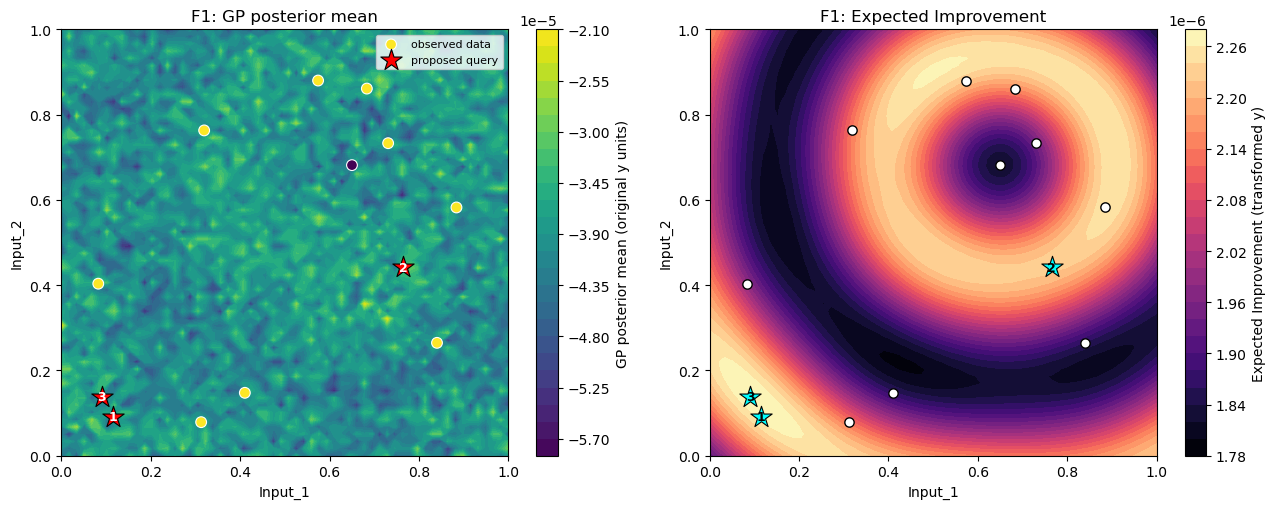

Saved figures\F2_gp_plane_ei.png


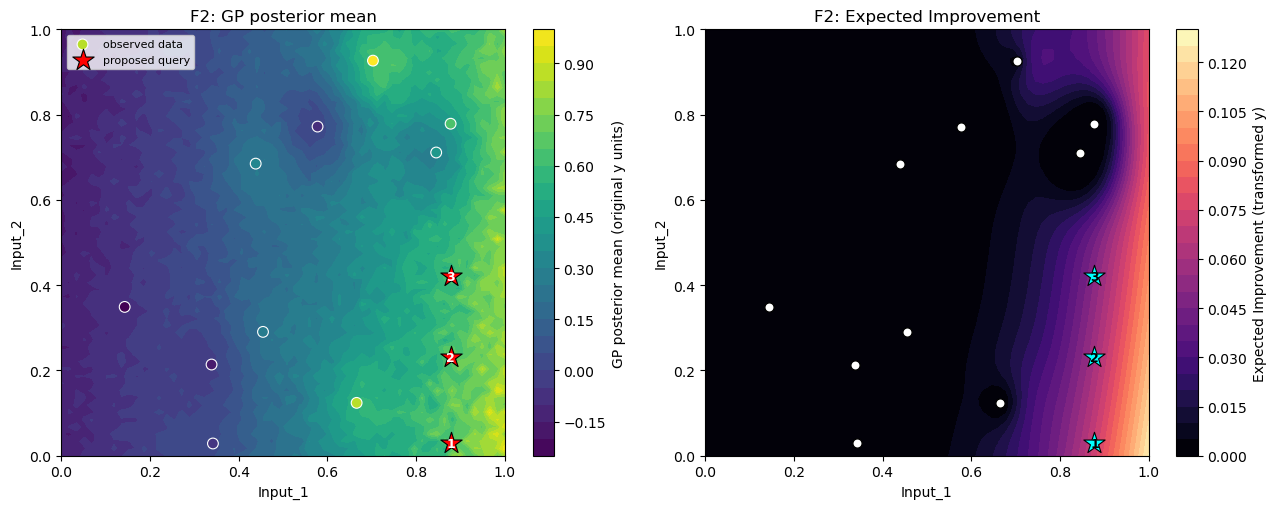

Saved figures\F3_gp_plane_ei.png


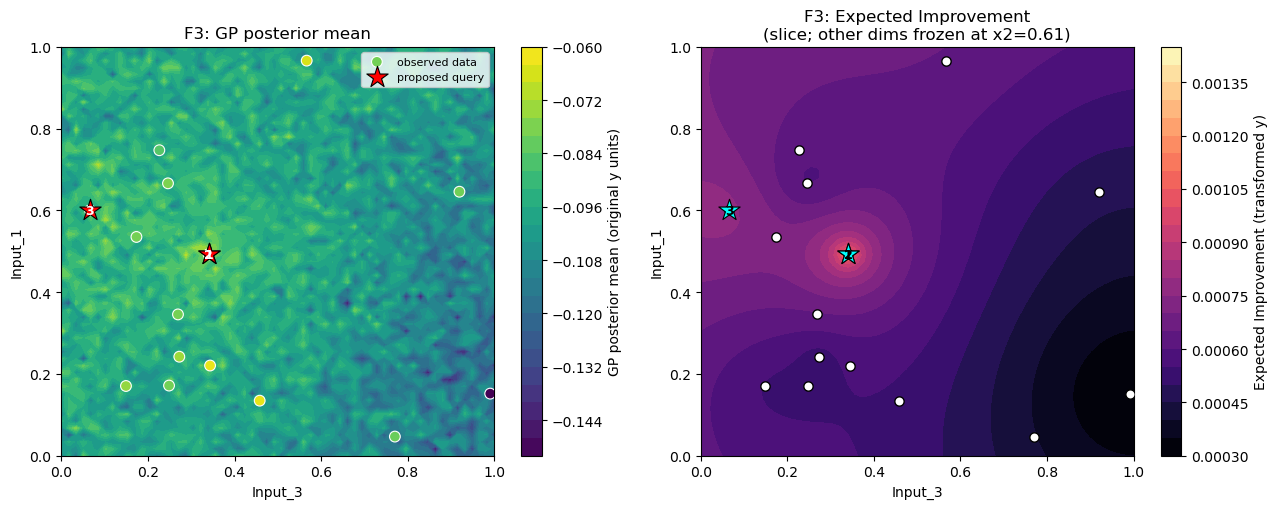

Saved figures\F4_gp_plane_ei.png


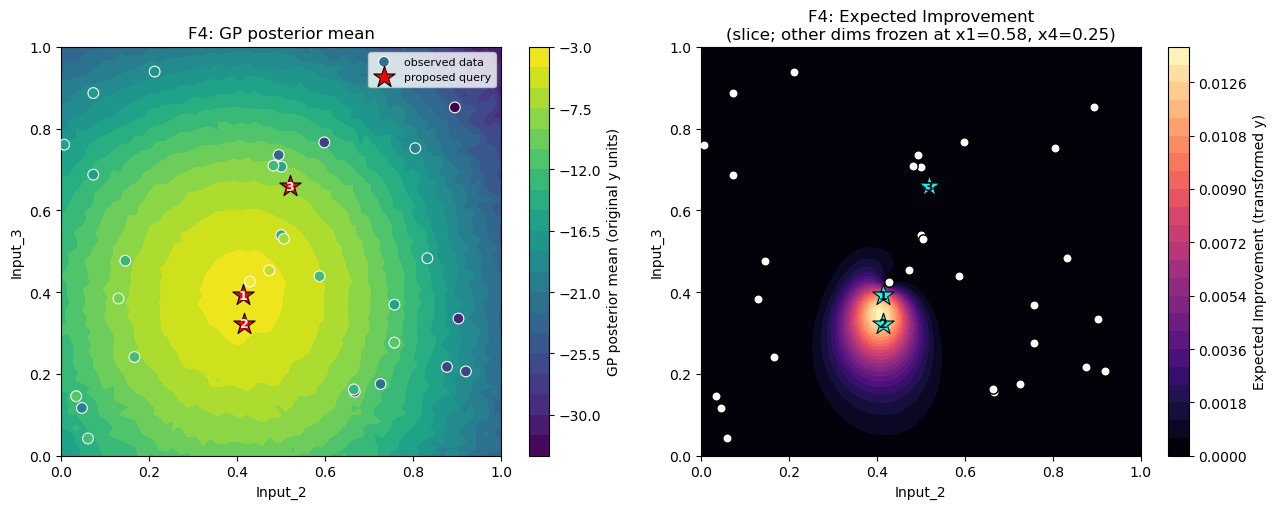

Saved figures\F5_gp_plane_ei.png


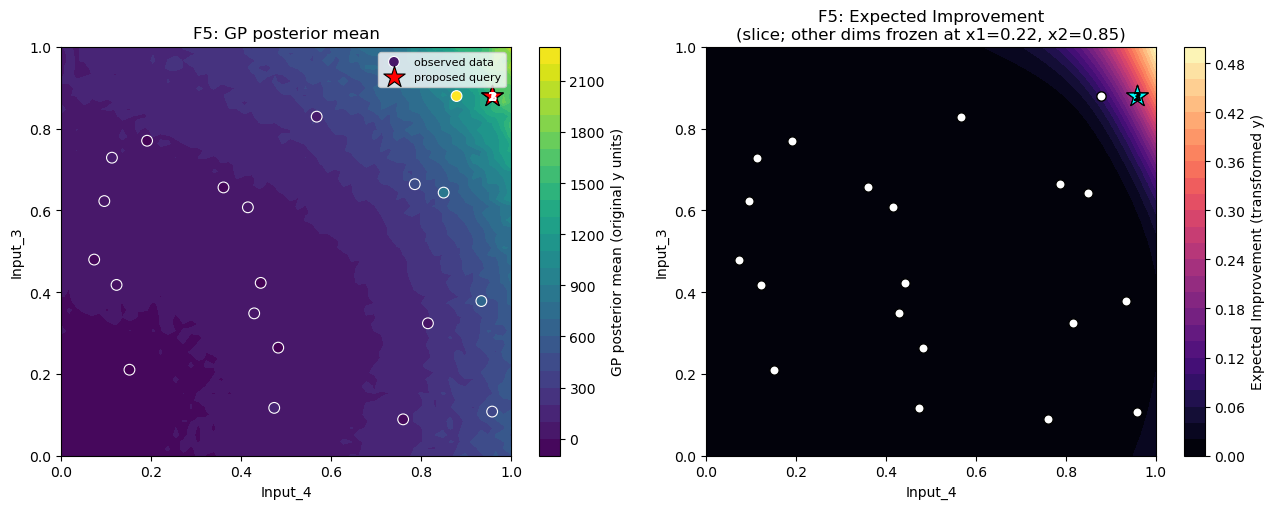

Saved figures\F6_gp_plane_ei.png


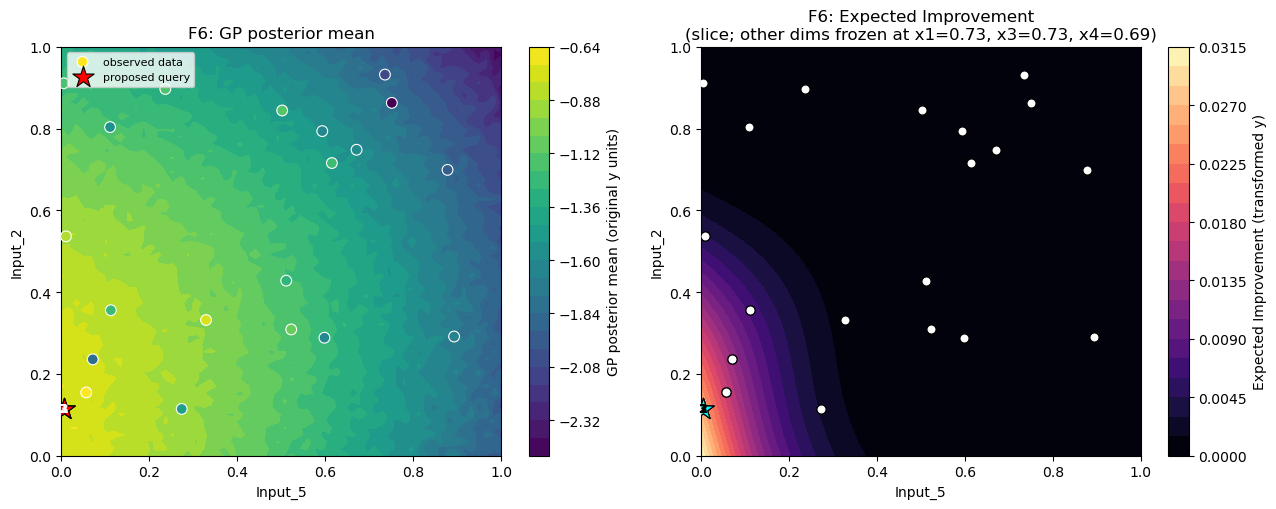

Saved figures\F7_gp_plane_ei.png


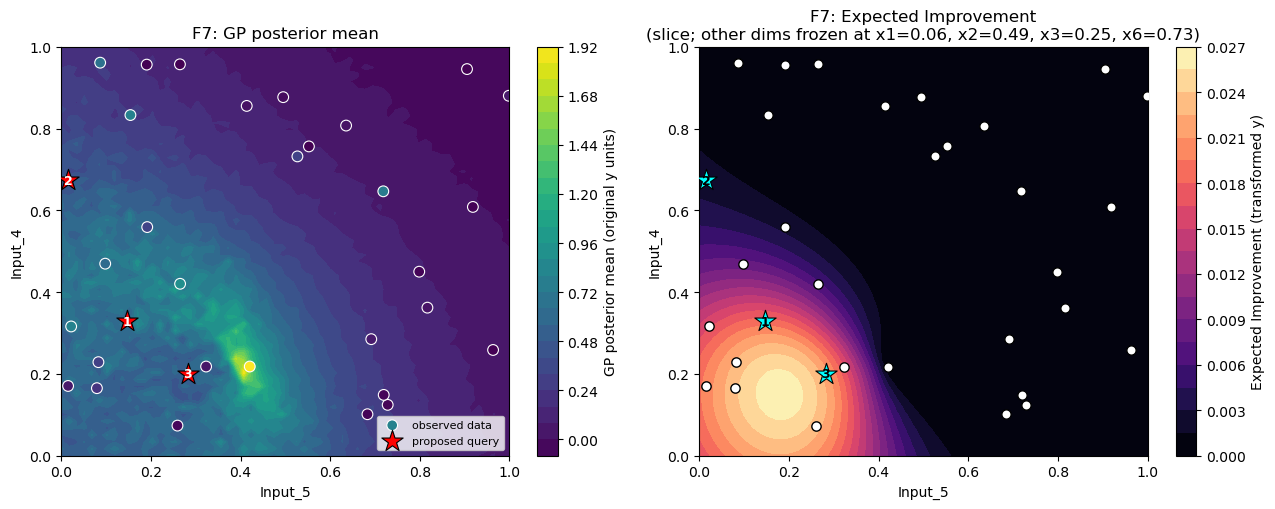

Saved figures\F8_gp_plane_ei.png


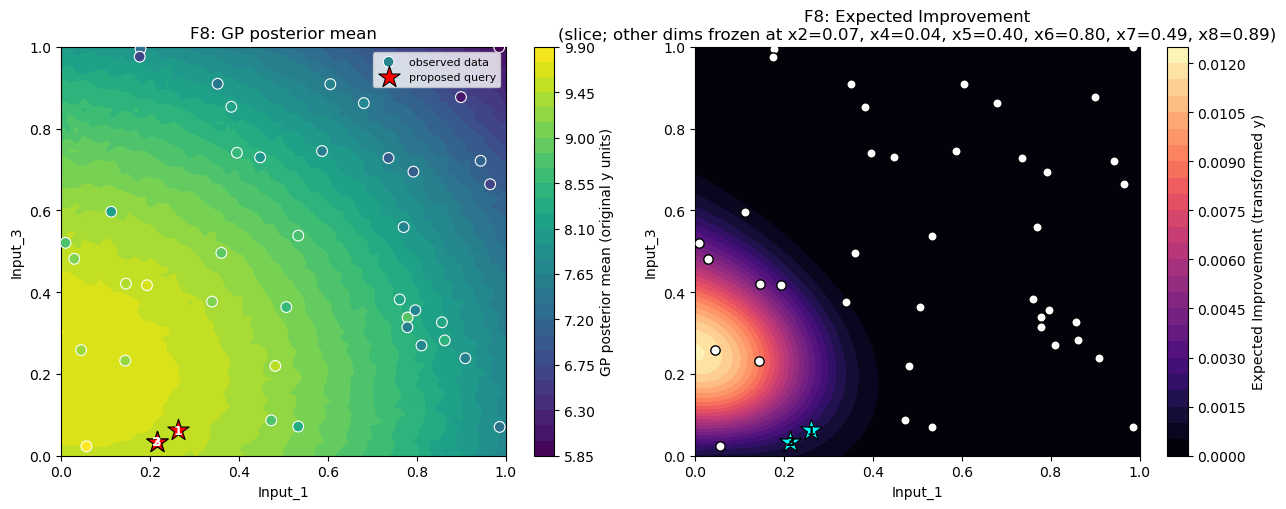

In [15]:
for fname, d in DATA.items():
    fig = plot_gp_plane(fname, BEST_CFG[fname], d["X"], d["y"], PROPOSALS[fname])
    save_fig(fig, f"{fname}_gp_plane_ei")
    plt.show()

## 12. Acquisition function comparison: EI vs. UCB vs. PI

Acquisition functions convert the Gaussian Process posterior mean $\mu(\mathbf{x})$ and variance $\sigma^2(\mathbf{x})$ into a scalar score indicating where to query next. Each handles the exploration-exploitation trade-off differently.

---

### Core Mechanics & Mathematical Formulations

* **Expected Improvement (EI)**

$$\text{EI}(\mathbf{x}) = (\mu(\mathbf{x}) - y_{\text{best}} - \xi)\Phi(Z) + \sigma(\mathbf{x})\phi(Z), \quad Z = \frac{\mu(\mathbf{x}) - y_{\text{best}} - \xi}{\sigma(\mathbf{x})}$$


* **Behavior:** Integrates over the magnitude of potential improvement. It rewards regions with high expected values as well as regions with high posterior uncertainty.
* **Exploration Parameter ($\xi$):** Offsets the target threshold. Higher values force the acquisition to favor uncertainty over immediate local returns.


* **Upper Confidence Bound (UCB)**

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa\,\sigma(\mathbf{x})$$


* **Behavior:** Represents an optimistic upper bound on function performance without referencing the current best value $y_{\text{best}}$.
* **Exploration Parameter ($\kappa$):** Directly scales the weight of uncertainty. $\kappa \to 0$ yields pure exploitation (greedy search), while large $\kappa$ drives pure exploration toward unmapped space.


* **Probability of Improvement (PI)**

$$\text{PI}(\mathbf{x}) = \Phi(Z) = \Phi\left(\frac{\mu(\mathbf{x}) - y_{\text{best}} - \xi}{\sigma(\mathbf{x})}\right)$$


* **Behavior:** Calculates the probability that a query exceeds $y_{\text{best}} + \xi$. It ignores the *amount* of improvement gained, focusing solely on the likelihood of beating the baseline.
* **Exploration Parameter ($\xi$):** Acts as a hard margin. Small values cause PI to become heavily exploitative, frequently proposing points near existing data boundaries.



---

### Trade-Off Summary

| Acquisition Function | Primary Focus | Strengths | Failure Modes / Drawbacks |
| --- | --- | --- | --- |
| **EI** | Balanced (Magnitude + Probability) | Well-scaled standard; robust baseline across diverse landscapes. | Can stall in low-variance regions if $\xi$ is set too small. |
| **UCB** | Tunable Optimism | Simple form; strong theoretical bounds (GP-UCB regret bounds). | Highly sensitive to $\kappa$; requires manual tuning across function scales. |
| **PI** | Pure Probability | Effective when any improvement over a threshold counts as a win. | Overly greedy; gets trapped locally by chasing tiny high-probability gains. |

---

In [16]:

def upper_confidence_bound(x_t, gp, kappa=2.0):
    x_t = np.atleast_2d(x_t)
    mu, sigma = gp.predict(x_t, return_std=True)
    return mu + kappa * sigma


def probability_of_improvement(x_t, gp, y_best, xi_abs):
    x_t = np.atleast_2d(x_t)
    mu, sigma = gp.predict(x_t, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - y_best - xi_abs) / sigma
    return norm.cdf(z)


def optimize_acquisition(acq_fn, xt, d, bounds, n_restarts=25, rng=None):
    # Generic multi-start L-BFGS-B optimiser: acq_fn takes transformed-x and
    # returns a (1,)-shaped array to be MAXIMISED.
    rng = np.random.default_rng(0) if rng is None else rng
    starts = rng.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(n_restarts, d))
    best_x, best_val = None, np.inf
    for s in starts:
        res = minimize(lambda x: -acq_fn(xt.transform(x.reshape(1, -1)))[0], s,
                        method="L-BFGS-B", bounds=bounds)
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x
    return best_x, -best_val


In [17]:

ACQ_KAPPA = 2.0
acq_rows = []
for fname, d in DATA.items():
    cfg = BEST_CFG[fname]
    gp, xt, yt = cfg["gp"], cfg["xt"], cfg["yt"]
    ys = yt.transform(d["y"])
    y_best = ys.max()
    y_spread = float(np.std(ys))
    xi_abs = 0.01 * y_spread if y_spread > 1e-12 else 1e-6
    bounds = [(0.0, 1.0)] * d["d"]

    x_ei, v_ei = optimize_acquisition(lambda xt_: expected_improvement(xt_, gp, y_best, xi_abs), xt, d["d"], bounds)
    x_ucb, v_ucb = optimize_acquisition(lambda xt_: upper_confidence_bound(xt_, gp, ACQ_KAPPA), xt, d["d"], bounds)
    x_pi, v_pi = optimize_acquisition(lambda xt_: probability_of_improvement(xt_, gp, y_best, xi_abs), xt, d["d"], bounds)

    dist_ei_ucb = float(np.linalg.norm(x_ei - x_ucb))
    dist_ei_pi = float(np.linalg.norm(x_ei - x_pi))
    acq_rows.append({"Function": fname, "EI argmax": np.round(x_ei, 3).tolist(),
                      "UCB argmax": np.round(x_ucb, 3).tolist(), "PI argmax": np.round(x_pi, 3).tolist(),
                      "||EI-UCB||": dist_ei_ucb, "||EI-PI||": dist_ei_pi})

acq_compare_df = pd.DataFrame(acq_rows)
acq_compare_df


,Function,EI argmax,UCB argmax,PI argmax,||EI-UCB||,||EI-PI||
0,F1,"[0.486, 0.889]","[0.486, 0.889]","[0.394, 0.643]",0.000000,0.263516
1,F2,"[1.0, 0.0]","[1.0, 0.0]","[1.0, 0.0]",0.000000,0.000000
2,F3,"[0.493, 0.612, 0.34]","[0.493, 0.612, 0.34]","[0.493, 0.612, 0.34]",0.000155,0.000014
3,F4,"[0.478, 0.413, 0.392, 0.348]","[0.443, 0.403, 0.371, 0.395]","[0.558, 0.426, 0.42, 0.259]",0.063001,0.123875
4,F5,"[0.276, 1.0, 1.0, 1.0]","[1.0, 1.0, 1.0, 1.0]","[0.245, 0.886, 0.942, 1.0]",0.723733,0.131123
5,F6,"[0.032, 0.0, 0.558, 1.0, 0.0]","[0.0, 0.0, 0.445, 1.0, 0.0]","[0.394, 0.229, 0.576, 0.857, 0.0]",0.117449,0.452007
6,F7,"[0.239, 0.209, 0.455, 0.328, 0.147, 0.789]","[0.254, 0.148, 0.404, 0.298, 0.116, 0.937]","[0.058, 0.481, 0.261, 0.217, 0.387, 0.733]",0.174503,0.466656
7,F8,"[0.0, 0.0, 0.0, 0.0, 0.788, 0.0, 0.0, 0.0]","[0.0, 0.241, 0.0, 0.0, 1.0, 0.0, 0.073, 0.0]","[0.267, 0.193, 0.045, 0.023, 0.696, 0.514, 0.4...",0.328874,1.125770


### Interpretation of Distance Metrics ($\vert{}\vert{}\text{EI}-\text{UCB}\vert{}\vert{}$ and $\vert{}\vert{}\text{EI}-\text{PI}\vert{}\vert{}$)

The Euclidean distance between acquisition optima in input space ($[0, 1]^d$) serves as a direct indicator of **surrogate confidence** and **landscape sensitivity**:

$$\Delta_{\text{UCB}} = \Vert{}\mathbf{x}^*_{\text{EI}} - \mathbf{x}^*_{\text{UCB}}\Vert{}_2, \qquad \Delta_{\text{PI}} = \Vert{}\mathbf{x}^*_{\text{EI}} - \mathbf{x}^*_{\text{PI}}\Vert{}_2$$

---

### Distance Regimes & Diagnostic Interpretations

* **Large Discrepancy ($\Delta \gg 0$): High Sensitivity / Uninformative Surrogate**
* **Landscape State:** High global uncertainty, sparse data density, or an extremely flat objective landscape (e.g., `F1`, where output values are flat across most of the domain).
* **Mechanism:** When posterior variance $\sigma(\mathbf{x})$ dominates or predictions are uniformly flat, small differences in acquisition mechanics drastically alter the optimal location:
* **PI** picks safe points right near the current empirical maximum $\mathbf{x}^+$.
* **UCB** (with higher $\kappa$) jumps toward unexplored boundaries with maximum variance $\sigma(\mathbf{x})$.
* **EI** balances between these two extremes.


* **Implication:** The choice of acquisition function is critical to optimisation trajectory performance.


* **Small Discrepancy ($\Delta \approx 0$): High Agreement / Well-Identified Optimum**
* **Landscape State:** Clear, localised peak with sufficient nearby sampling.
* **Mechanism:** Strong gradients in the posterior mean $\mu(\mathbf{x})$ overpower the variance term $\sigma(\mathbf{x})$. The magnitude of prospective gain at the peak outweighs pure exploration incentives across all three formulations.
* **Implication:** Optimisation has entered an exploitation phase; choice of acquisition function yields minor local variations.

Saved figures\F2_acquisition_comparison.png


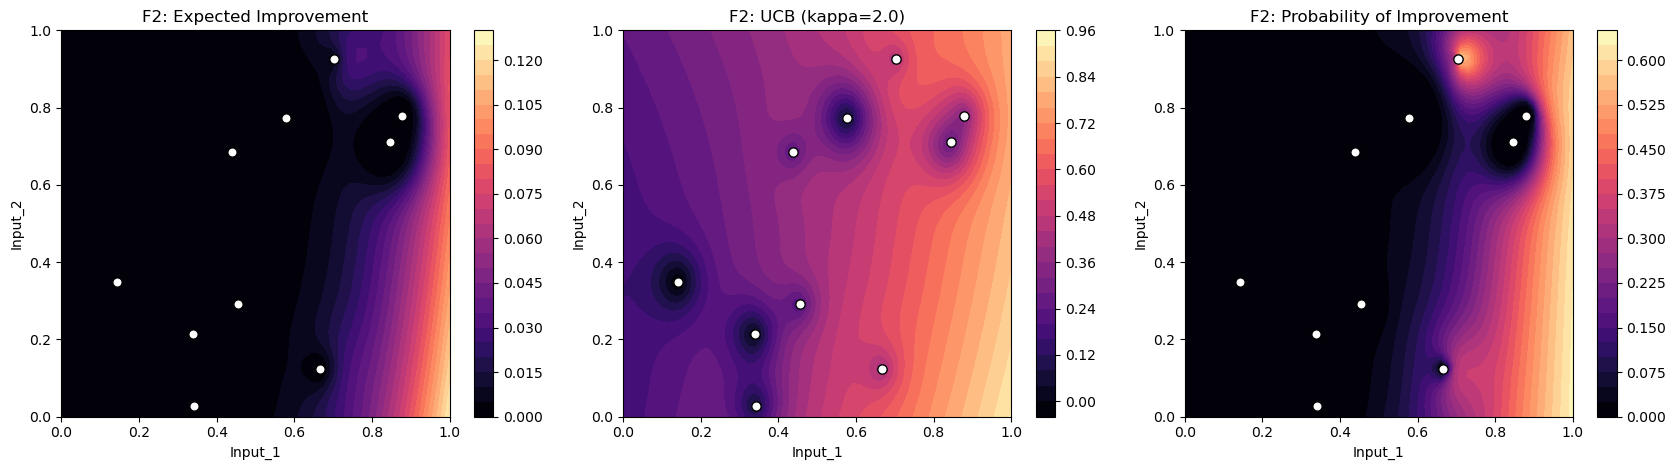

In [18]:
# Visualise the three acquisition surfaces side-by-side for one representative
# 2-D function (F2) where all three can be plotted directly without slicing.
fname = "F2"
cfg, d = BEST_CFG[fname], DATA[fname]
gp, xt, yt = cfg["gp"], cfg["xt"], cfg["yt"]
X, y = d["X"], d["y"]
ys = yt.transform(y)
y_best = ys.max()
y_spread = float(np.std(ys))
xi_abs = 0.01 * y_spread if y_spread > 1e-12 else 1e-6

grid = np.linspace(0.0, 1.0, GRID_N)
Gi, Gj = np.meshgrid(grid, grid)
pts = np.c_[Gi.ravel(), Gj.ravel()]
pts_t = xt.transform(pts)

ei_surf = expected_improvement(pts_t, gp, y_best, xi_abs).reshape(GRID_N, GRID_N)
ucb_surf = upper_confidence_bound(pts_t, gp, ACQ_KAPPA).reshape(GRID_N, GRID_N)
pi_surf = probability_of_improvement(pts_t, gp, y_best, xi_abs).reshape(GRID_N, GRID_N)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, surf, title, cmap in zip(axes, [ei_surf, ucb_surf, pi_surf],
                                  ["Expected Improvement", f"UCB (kappa={ACQ_KAPPA})", "Probability of Improvement"],
                                  ["magma", "magma", "magma"]):
    cf = ax.contourf(Gi, Gj, surf, levels=25, cmap=cmap)
    fig.colorbar(cf, ax=ax)
    ax.scatter(X[:, 0], X[:, 1], c="white", edgecolor="black", s=45, zorder=3)
    ax.set_xlabel("Input_1"); ax.set_ylabel("Input_2"); ax.set_title(f"{fname}: {title}")

plt.tight_layout()
save_fig(fig, f"{fname}_acquisition_comparison")
plt.show()

Saved figures\F2_batch_strategy_comparison.png


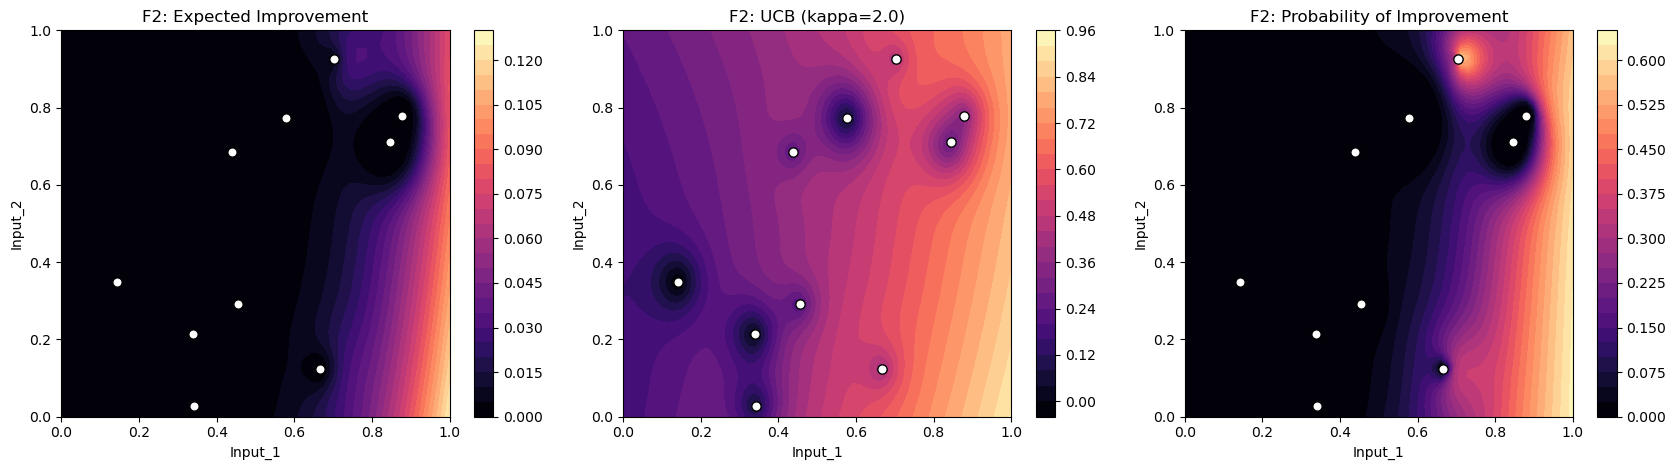

In [19]:
# Visualise the three acquisition surfaces side-by-side for one representative
# 2-D function (F2) where all three can be plotted directly without slicing.
fname = "F2"
cfg, d = BEST_CFG[fname], DATA[fname]
gp, xt, yt = cfg["gp"], cfg["xt"], cfg["yt"]
X, y = d["X"], d["y"]
ys = yt.transform(y)
y_best = ys.max()
y_spread = float(np.std(ys))
xi_abs = 0.01 * y_spread if y_spread > 1e-12 else 1e-6

grid = np.linspace(0.0, 1.0, GRID_N)
Gi, Gj = np.meshgrid(grid, grid)
pts = np.c_[Gi.ravel(), Gj.ravel()]
pts_t = xt.transform(pts)

ei_surf = expected_improvement(pts_t, gp, y_best, xi_abs).reshape(GRID_N, GRID_N)
ucb_surf = upper_confidence_bound(pts_t, gp, ACQ_KAPPA).reshape(GRID_N, GRID_N)
pi_surf = probability_of_improvement(pts_t, gp, y_best, xi_abs).reshape(GRID_N, GRID_N)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, surf, title, cmap in zip(axes, [ei_surf, ucb_surf, pi_surf],
                                  ["Expected Improvement", f"UCB (kappa={ACQ_KAPPA})", "Probability of Improvement"],
                                  ["magma", "magma", "magma"]):
    cf = ax.contourf(Gi, Gj, surf, levels=25, cmap=cmap)
    fig.colorbar(cf, ax=ax)
    ax.scatter(X[:, 0], X[:, 1], c="white", edgecolor="black", s=45, zorder=3)
    ax.set_xlabel("Input_1"); ax.set_ylabel("Input_2"); ax.set_title(f"{fname}: {title}")

plt.tight_layout()
save_fig(fig, f"{fname}_batch_strategy_comparison")
plt.show()

In [20]:
def estimate_lipschitz(gp, xt, d, n_samples=200, eps=1e-4, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    pts = rng.uniform(0.0, 1.0, size=(n_samples, d))
    grad_norms = np.zeros(n_samples)
    for idx, p in enumerate(pts):
        g = np.zeros(d)
        for k in range(d):
            pp, pm = p.copy(), p.copy()
            pp[k] += eps; pm[k] -= eps
            g[k] = (gp.predict(xt.transform(pp.reshape(1, -1)))[0]
                     - gp.predict(xt.transform(pm.reshape(1, -1)))[0]) / (2 * eps)
        grad_norms[idx] = np.linalg.norm(g)
    return max(float(np.max(grad_norms)), 1e-6)


def _local_penalizer(x_raw, x_j_raw, mu_j, sigma_j, M, L):
    r_j = (M - mu_j) / L
    s_j = max(sigma_j / L, 1e-9)
    dist = np.linalg.norm(x_raw - x_j_raw.reshape(1, -1), axis=1)
    return norm.cdf((dist - r_j) / s_j)


def propose_queries_local_penalization(cfg, X, y, bounds=None, n_queries=3, xi=0.01,
                                        n_restarts=25, rng=None):
    rng = np.random.default_rng(1) if rng is None else rng
    d = X.shape[1]
    if bounds is None:
        lo, hi = X.min(axis=0), X.max(axis=0)
        bounds = list(zip(np.maximum(lo, 0.0), np.minimum(hi, 1.0)))

    xt, yt, gp = cfg["xt"], cfg["yt"], cfg["gp"]
    ys = yt.transform(y)
    y_best = ys.max()
    y_spread = float(np.std(ys))
    xi_abs = xi * y_spread if y_spread > 1e-12 else 1e-6

    L = estimate_lipschitz(gp, xt, d, rng=rng)
    scan = rng.uniform(0.0, 1.0, size=(500, d))
    M = max(float(gp.predict(xt.transform(scan)).max()), y_best)

    selected_raw, selected_mu, selected_sigma = [], [], []

    def penalized_neg_ei(x_raw):
        x_raw2 = x_raw.reshape(1, -1)
        ei = expected_improvement(xt.transform(x_raw2), gp, y_best, xi_abs)[0]
        for xj, muj, sj in zip(selected_raw, selected_mu, selected_sigma):
            ei *= _local_penalizer(x_raw2, xj, muj, sj, M, L)[0]
        return -ei

    proposals = []
    for q in range(n_queries):
        best_x, best_val = None, np.inf
        starts = rng.uniform([b[0] for b in bounds], [b[1] for b in bounds], size=(n_restarts, d))
        for s in starts:
            res = minimize(penalized_neg_ei, s, method="L-BFGS-B", bounds=bounds)
            if res.fun < best_val:
                best_val, best_x = res.fun, res.x
        best_x = np.clip(best_x, [b[0] for b in bounds], [b[1] for b in bounds])

        mu_t, sd_t = gp.predict(xt.transform(best_x.reshape(1, -1)), return_std=True)
        selected_raw.append(best_x); selected_mu.append(float(mu_t[0])); selected_sigma.append(float(sd_t[0]))

        samples_orig = safe_inverse_transform(yt, rng.normal(mu_t[0], sd_t[0], size=2000), ys)
        proposals.append({"x": best_x, "ei": float(-best_val),
                           "pred_mean_orig": float(np.mean(samples_orig)),
                           "pred_std_orig": float(np.std(samples_orig))})
    return proposals


def batch_diversity(proposals):
    # Mean pairwise Euclidean distance between proposed points (raw-x space).
    Xp = np.array([p["x"] for p in proposals])
    n = len(Xp)
    if n < 2:
        return 0.0
    dists = [np.linalg.norm(Xp[a] - Xp[b]) for a in range(n) for b in range(a + 1, n)]
    return float(np.mean(dists))


In [21]:
LP_PROPOSALS = {}
batch_rows = []
for fname, d in DATA.items():
    lp_props = propose_queries_local_penalization(BEST_CFG[fname], d["X"], d["y"], n_queries=N_QUERIES)
    LP_PROPOSALS[fname] = lp_props
    kb_div = batch_diversity(PROPOSALS[fname])
    lp_div = batch_diversity(lp_props)
    batch_rows.append({"Function": fname, "Kriging-Believer diversity": kb_div,
                        "Local-Penalization diversity": lp_div,
                        "LP more diverse?": lp_div > kb_div})

batch_compare_df = pd.DataFrame(batch_rows)
batch_compare_df


,Function,Kriging-Believer diversity,Local-Penalization diversity,LP more diverse?
0,F1,0.510284,0.698116,True
1,F2,0.261596,0.181971,False
2,F3,0.210382,0.728581,True
3,F4,0.565571,0.032196,False
4,F5,0.144573,0.133563,False
5,F6,0.102330,0.340141,True
6,F7,0.831480,0.177204,False
7,F8,0.232353,0.756742,True


### Batch Diversity & Acquisition Heuristics

Batch diversity is quantified by the mean pairwise Euclidean distance across the recommended candidate points $\mathbf{X}_{\text{batch}} = \{\mathbf{x}_1^*, \dots, \mathbf{x}_k^*\}$:

$$\text{Diversity}(\mathbf{X}_{\text{batch}}) = \frac{2}{k(k-1)} \sum_{1 \le i < j \le k} \Vert{}\mathbf{x}_i^* - \mathbf{x}_j^*\Vert{}_2$$

Higher values indicate that candidate proposals are geographically distributed throughout $[0, 1]^d$, whereas lower values indicate tight clustering around local maxima.

---

### Mechanical Comparison: Kriging Believer vs. Local Penalisation

* **Kriging Believer (KB)**
* **Mechanism:** Temporarily sets the unknown objective value at a proposed point to the GP posterior mean: $\hat{y}^* = \mu(\mathbf{x}^*)$.
* **Behavior:** Collapses variance locally ($\sigma(\mathbf{x}^*) \to 0$), which drops the immediate local acquisition score. However, because it assumes the local mean prediction is accurate, subsequent candidates remain clustered around high-promising regions if the predicted peak is broad.
* **Best Use Case:** Exploitation-heavy parallel batches where the primary goal is refining an existing, highly-probable basin of attraction.


* **Local Penalisation (LP)**
* **Mechanism:** Multiplies the baseline acquisition function by a local sphere of influence (penalisation function $\phi(\mathbf{x})$) around each proposed point $\mathbf{x}_j^*$:

$$\text{Acq}_j(\mathbf{x}) = \text{Acq}_0(\mathbf{x}) \prod_{l=1}^{j-1} \phi(\mathbf{x}; \mathbf{x}_l^*, L)$$



The radius of penalisation is governed by the estimated global or local **Lipschitz constant** $L = \max \Vert{}\nabla f(\mathbf{x})\Vert{}$.
* **Behavior:** Explicitly carves out spatial exclusion zones around selected candidates. This forces subsequent proposals to jump to distinct local modes or high-uncertainty regions elsewhere in the input domain.
* **Best Use Case:** True parallel exploration where batch queries are evaluated simultaneously and hedging against multi-modal landscapes is essential.

---

### Strategy Selection Criteria

| Dimension | Kriging Believer | Local Penalization |
| --- | --- | --- |
| **Spatial Behavior** | Concentrated local search | Distributed global coverage |
| **Primary Driver** | Variance reduction via imputed mean | Lipschitz-bounded exclusion zones |
| **Computational Overhead** | High (requires full GP refit per batch item) | Low (multiplies analytic penalty; no refits) |
| **Sensitivity** | Robust to scaling; hyperparameter-free | Sensitive to Lipschitz constant estimation $L$ |

---

**Batch Diversity Definition**
"Diversity" refers to the mean pairwise Euclidean distance (in raw x-space) among the 3 proposed query points. Higher values indicate that the batch spreads across the space rather than clustering tightly in one location.

**Strategy Trade-Offs**
Neither strategy is strictly superior; they represent different trade-offs:

* **Kriging Believer:** Tends to stay focused around the single most promising region already identified by the surrogate model.
* **Local Penalization:** Actively forces subsequent points away from earlier selections whenever the Lipschitz bound suggests high potential elsewhere. This makes it ideal for parallel evaluations where hedging across multiple regions of the input space is preferred.

Saved figures\F2_kriging_believer_local_penalisation.png


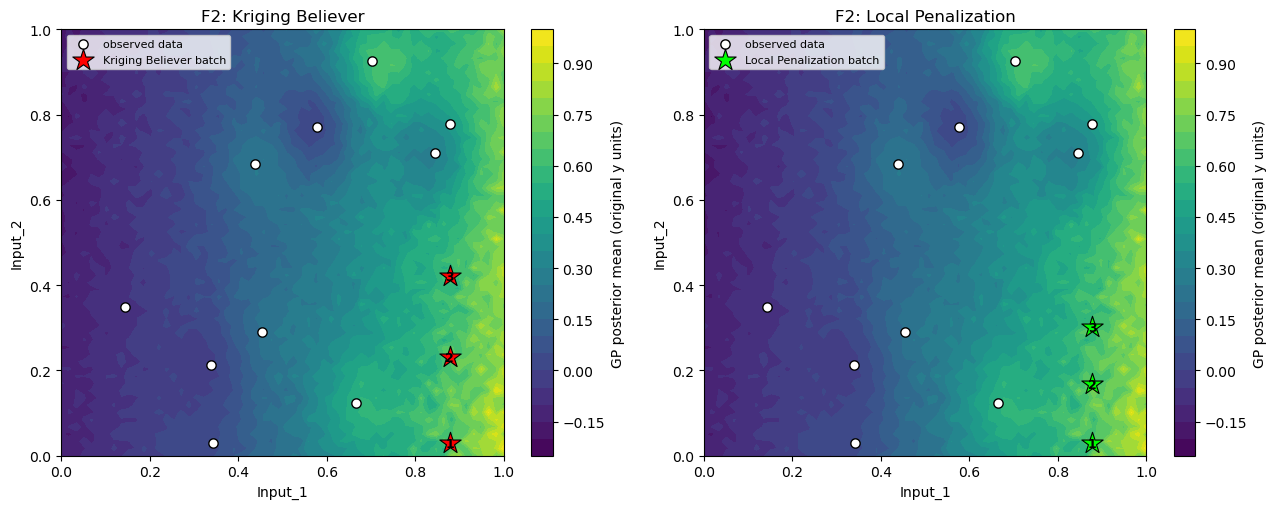

Saved figures\F8_kriging_believer_local_penalisation.png


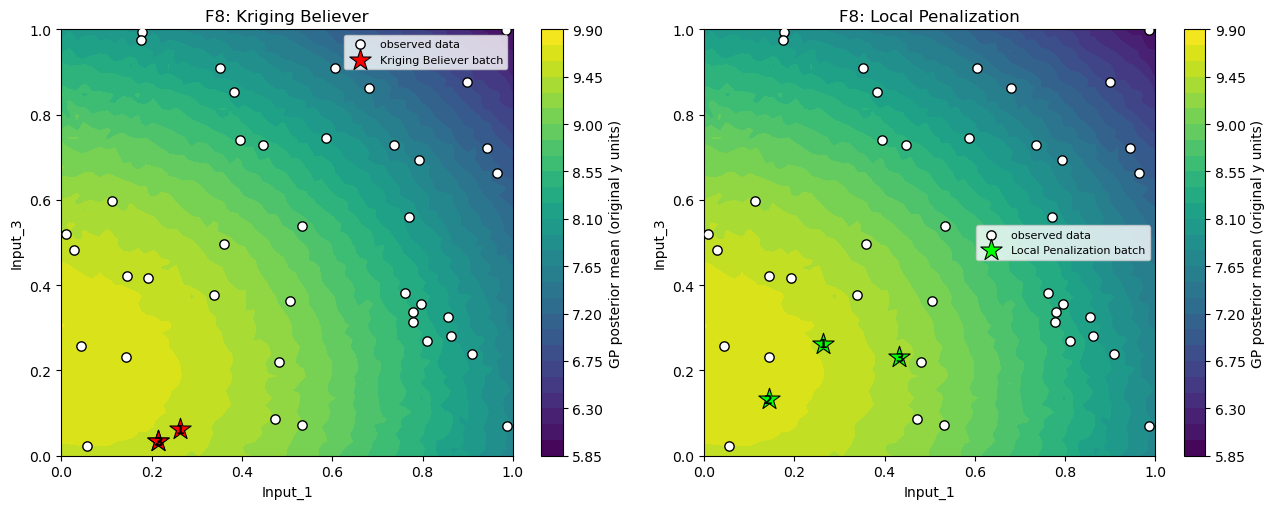

In [22]:

# Visualise both batches on the GP plane for a couple of representative functions.
for fname in ["F2", "F8"]:
    cfg, d = BEST_CFG[fname], DATA[fname]
    X, y = d["X"], d["y"]
    gp, xt, yt = cfg["gp"], cfg["xt"], cfg["yt"]
    dd = X.shape[1]
    x_ref = X[np.argmax(y)].copy()
    if dd <= 2:
        i, j = 0, 1
    else:
        order, _ = sensitivity_ranking(cfg, X, x_ref)
        i, j = order[:2]

    grid = np.linspace(0.0, 1.0, GRID_N)
    Gi, Gj = np.meshgrid(grid, grid)
    pts = np.tile(x_ref, (GRID_N * GRID_N, 1)).astype(float)
    pts[:, i], pts[:, j] = Gi.ravel(), Gj.ravel()
    mu_t, sd_t = gp.predict(xt.transform(pts), return_std=True)
    rng = np.random.default_rng(0)
    ys = yt.transform(y)
    samp_t = rng.normal(mu_t, sd_t, size=(60, mu_t.shape[0]))
    mu_orig = safe_inverse_transform(yt, samp_t.ravel(), ys).reshape(60, -1).mean(axis=0).reshape(GRID_N, GRID_N)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    for ax, props, label, marker_c in zip(axes, [PROPOSALS[fname], LP_PROPOSALS[fname]],
                                           ["Kriging Believer", "Local Penalization"], ["red", "lime"]):
        cf = ax.contourf(Gi, Gj, mu_orig, levels=25, cmap="viridis")
        fig.colorbar(cf, ax=ax, label="GP posterior mean (original y units)")
        ax.scatter(X[:, i], X[:, j], c="white", edgecolor="black", s=45, zorder=3, label="observed data")
        Xp = np.array([p["x"] for p in props])
        ax.scatter(Xp[:, i], Xp[:, j], marker="*", c=marker_c, s=260, edgecolor="black",
                   linewidth=0.8, zorder=4, label=f"{label} batch")
        for k in range(len(props)):
            ax.annotate(str(k + 1), (Xp[k, i], Xp[k, j]), color="black", ha="center",
                        va="center", fontsize=9, fontweight="bold", zorder=5)
        ax.set_xlabel(f"Input_{i+1}"); ax.set_ylabel(f"Input_{j+1}")
        ax.set_title(f"{fname}: {label}"); ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    save_fig(fig, f"{fname}_kriging_believer_local_penalisation")
    plt.show()

## 14. Summary

* **`summary` (Section 7):** Details the OAT-selected kernel, x-transform, and y-transform for each function, alongside their analytical LOO-NLPD, LOO-RMSE (computed in the optimized transformed-y space), and LOO-R2 metrics.
* **`queries_df` (Section 9):** Saved as `proposed_queries.csv`, this lists the top 3 recommended next evaluation points per function. Each entry includes its Expected Improvement (EI) value and GP-predicted output, back-transformed to original units using Monte Carlo simulation due to nonlinear y-transforms.
* **Visualization (Section 11):** Displays the GP posterior mean and EI surface overlaid with observed data and proposed queries for every function. For functions with $d > 2$, plots display a 2D slice along the two most OAT-sensitive input dimensions, keeping all remaining dimensions fixed at the best observed point.
* **Acquisition Comparison (Section 12):** Evaluates EI against UCB and PI using `acq_compare_df`. It highlights where each function's acquisition optima land and measures their spatial separation—indicating whether acquisition selection fundamentally alters the decision or if the surrogate is simply confident about a clear peak.
* **Batch Strategy Comparison (Section 13):** Uses `batch_compare_df` and side-by-side plots on `F2` and `F8` to contrast two batch-diversification methods: Kriging Believer and Local Penalisation.

**Key Caveats:**

* **Search Approximations:** OAT hyperparameter selection uses coordinate descent across the 304-point grid. As a result, it may miss globally optimal (kernel, transform) combinations that require joint axis optimization.
* **Metric Alignment:** LOO-NLPD balances point prediction with variance calibration rather than directly scoring optimization success. Additionally, with small sample sizes (10–40 points per function), some kernels struggle with identifiability—notably `F1`, where outputs span ~100 orders of magnitude and flatten outside a sharp peak.
* **Dimensionality Slices:** For $d > 2$ functions, EI optimization runs across the full $d$-dimensional space via multi-start L-BFGS-B. Visualizations only show a 2D projection, meaning proposed points may appear to overlap if their differences lie in unplotted dimensions.
* **Batch Heuristics:** Kriging Believer and Local Penalization both approximate true joint $q$-EI acquisition. Local Penalization relies on a single global Lipschitz constant ($L$), coarsely estimated here from 200 finite-difference gradient samples. Both approaches represent standard, pragmatic trade-offs for small batch sizes.
* **Static Hyperparameters:** UCB relies on a fixed exploration parameter ($\kappa = 2.0$). Practical sequential implementations typically tune or anneal $\kappa$ across iterations instead of holding it constant.

**High-Priority Experiments**

* **Sequential BO Loop:** Run 5–10 iterative propose–observe–retune cycles across 2–3 functions. Plot best-observed value versus iteration to prove end-to-end functionality.
* **Held-Out Regret Simulation:** Hide the last 30–40% of existing data to test how quickly different acquisition functions (EI, UCB, PI) rediscover the known optimum.

**Algorithmic & Surrogate Upgrades**

* **Monte Carlo q-EI:** Implement true joint batch acquisition to benchmark the efficiency loss of the Kriging Believer and Local Penalization heuristics.
* **ARD Kernels:** Enable per-dimension length-scales for high-dimensional functions (F4–F8) so feature importance is learned directly during surrogate fitting.
* **Full Bayesian Hyperparameters:** Marginalize over kernel hyperparameters (via MCMC or multi-restart ensembling) to prevent overfitting on small datasets (F1, F2).
* **Baseline Benchmarks:** Compare the GP surrogate against Random Forest and Gradient Boosting models using existing LOO-CV metrics.

**Validation & Analysis**

* **Sobol Sensitivity Analysis:** Replace One-At-a-Time (OAT) sweeps with global Sobol indices to capture parameter interactions for multi-dimensional plotting.
* **OAT vs. Full Grid Search:** Benchmark OAT coordinate descent against a full 304-point grid on 2 functions to quantify approximation error and failure modes.
* **Uncertainty Calibration:** Build LOO predictive interval calibration plots (e.g., 90% coverage) to verify that posterior variance estimates are reliable.

**Packaging**

* **Reproducibility:** Add environment requirements and write a brief summary report to package the notebook as a standalone deliverable.

---